# Imports

In [1]:
import os, sys
import pandas as pd

# Setup path to project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    render_table2_accuracy,
    render_table2_runtime,
    run_and_plot_errors_vary_m,
    plot_convergence
)

from Tests.CPU.testing_helpers import (
    RADIAL_METHODS,
    run_NM_radial_sweep,
    run_bc_quad_radial_sweep,
    render_NM_radial_accuracy,
    render_NM_radial_runtime,
    render_bc_quad_radial_accuracy,
    render_bc_quad_radial_runtime,
    plot_radial_accuracy_vs_M,
    plot_radial_accuracy_vs_N,
    plot_radial_runtime_vs_M,
    plot_bc_quad_radial_accuracy,
    plot_bc_quad_comparison_vs_M,
    plot_convergence,
)

# Parameters

In [2]:
# ── Edit these freely ────────────────────────────────────────────────────────

N_VALS  = [32, 64, 128, 256, 512]   # angular point counts
M_VALS  = [32, 64, 128, 256, 512]   # radial  point counts
N_FIXED = 128                        # fixed N used in the BC/quad sweep

# Subset of RADIAL_METHODS to run (comment out any you want to skip)
ACTIVE_METHODS = RADIAL_METHODS      # all five by default

MUTE = False   # True = suppress per-case print output

In [3]:
# Run Tests

In [4]:
print("Running N × M sweep...")
df_nm = run_NM_radial_sweep(
    N_values=N_VALS,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    bc_choice=1,    # Dirichlet
    quad_rule=1,    # Trapezoidal
    mute=MUTE,
)
print("Done.")

print(f"Running BC × quadrature sweep  (N = {N_FIXED})...")
df_bq = run_bc_quad_radial_sweep(
    N_fixed=N_FIXED,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    mute=MUTE,
)
print("Done.")

Running N × M sweep...

── Uniform Radial ──
  N=  32, M=  32 | L2_rel=1.098e-05 | t=0.358s
  N=  32, M=  64 | L2_rel=2.661e-06 | t=0.008s
  N=  32, M= 128 | L2_rel=6.548e-07 | t=0.019s
  N=  32, M= 256 | L2_rel=1.624e-07 | t=0.012s
  N=  32, M= 512 | L2_rel=4.045e-08 | t=0.058s
  N=  64, M=  32 | L2_rel=1.098e-05 | t=0.006s
  N=  64, M=  64 | L2_rel=2.661e-06 | t=0.011s
  N=  64, M= 128 | L2_rel=6.548e-07 | t=0.011s
  N=  64, M= 256 | L2_rel=1.624e-07 | t=0.019s
  N=  64, M= 512 | L2_rel=4.045e-08 | t=0.049s
  N= 128, M=  32 | L2_rel=1.098e-05 | t=0.012s
  N= 128, M=  64 | L2_rel=2.661e-06 | t=0.007s
  N= 128, M= 128 | L2_rel=6.548e-07 | t=0.025s
  N= 128, M= 256 | L2_rel=1.624e-07 | t=0.027s
  N= 128, M= 512 | L2_rel=4.045e-08 | t=0.134s
  N= 256, M=  32 | L2_rel=1.098e-05 | t=0.010s
  N= 256, M=  64 | L2_rel=2.661e-06 | t=0.014s
  N= 256, M= 128 | L2_rel=6.548e-07 | t=0.031s
  N= 256, M= 256 | L2_rel=1.624e-07 | t=0.093s
  N= 256, M= 512 | L2_rel=4.045e-08 | t=0.223s
  N= 512, M=  3

# accuracy 

In [5]:
render_NM_radial_accuracy(df_nm)


render_bc_quad_radial_accuracy(df_bq)


Uniform Radial Accuracy


M,32,64,128,256,512
N,,,,,
32,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
64,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
128,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
256,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
512,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08



Nonuniform (sqrt) Accuracy


M,32,64,128,256,512
N,,,,,
32,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
64,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
128,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
256,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
512,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07



Nonuniform (rand) Accuracy


M,32,64,128,256,512
N,,,,,
32,2.99e-04,3.54e-04,3.33e-04,2.57e-04,1.55e-04
64,5.27e-03,2.69e-04,1.35e-03,1.14e-04,5.54e-05
128,2.59e-03,2.12e-04,5.51e-05,9.69e-05,4.37e-05
256,3.53e-04,3.23e-03,5.72e-04,7.93e-05,8.85e-05
512,2.06e-03,1.27e-03,1.16e-03,6.86e-05,4.42e-04



BC × Quad Accuracy Accuracy


# runtime

In [6]:
render_NM_radial_runtime(df_nm)


render_bc_quad_radial_runtime(df_bq)


Uniform Radial Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.3576,0.0083,0.0193,0.0122,0.0579
64,0.0060,0.0108,0.0105,0.0190,0.0485
128,0.0116,0.0071,0.0246,0.0269,0.1344
256,0.0101,0.0138,0.0307,0.0933,0.2232
512,0.0164,0.0308,0.0762,0.2162,0.3866



Nonuniform (sqrt) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0038,0.0066,0.0059,0.0133,0.0310
64,0.0032,0.0085,0.0103,0.0156,0.0370
128,0.0082,0.0084,0.0139,0.0289,0.0890
256,0.0058,0.0132,0.0243,0.0622,0.1537
512,0.0126,0.0259,0.0770,0.1505,0.3263



Nonuniform (rand) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0028,0.0041,0.0053,0.0124,0.0165
64,0.0035,0.0047,0.0121,0.0152,0.0320
128,0.0041,0.0072,0.0144,0.0211,0.1057
256,0.0100,0.0140,0.0542,0.0886,0.1647
512,0.0104,0.0308,0.0556,0.1484,0.3041



BC × Quad Runtime Runtime (s)


# Accuracy Plots

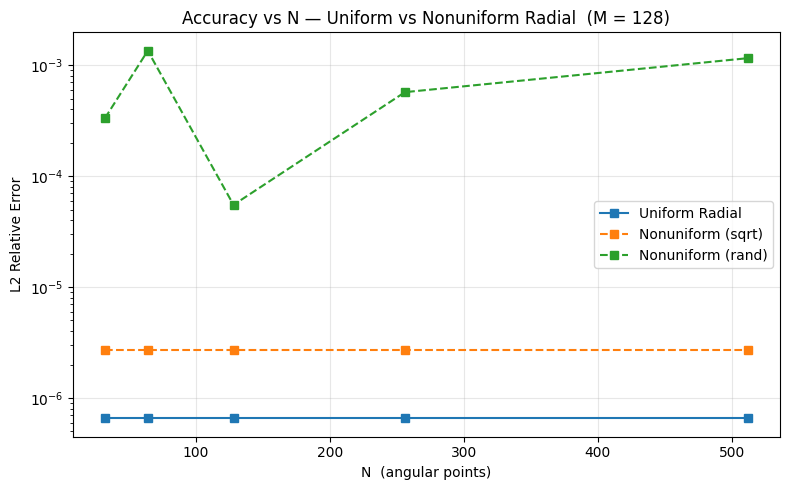

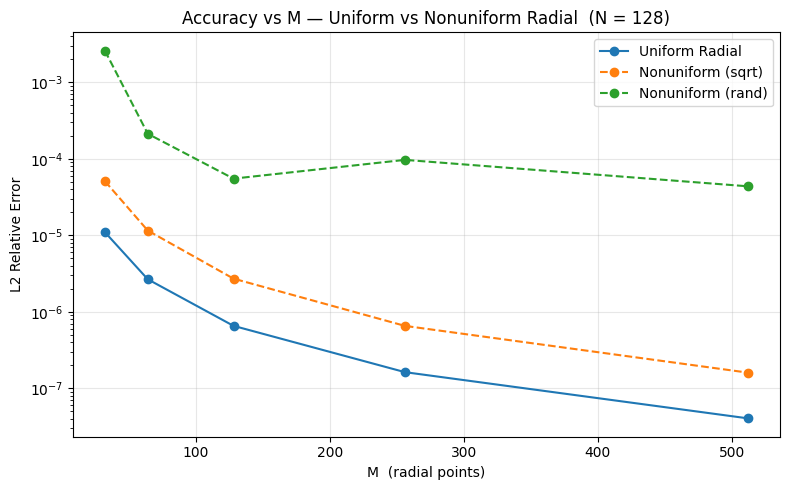

In [7]:
plot_radial_accuracy_vs_N(df_nm, M_fixed=M_VALS[len(M_VALS)//2])

plot_radial_accuracy_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])


# Runtime Plots

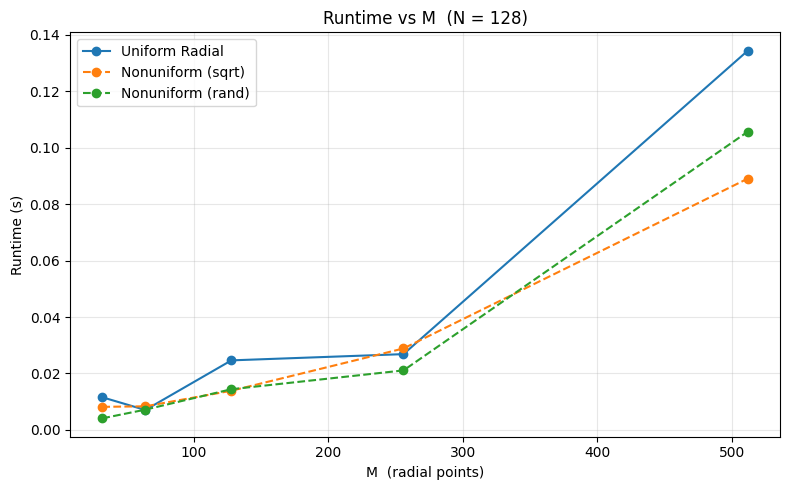

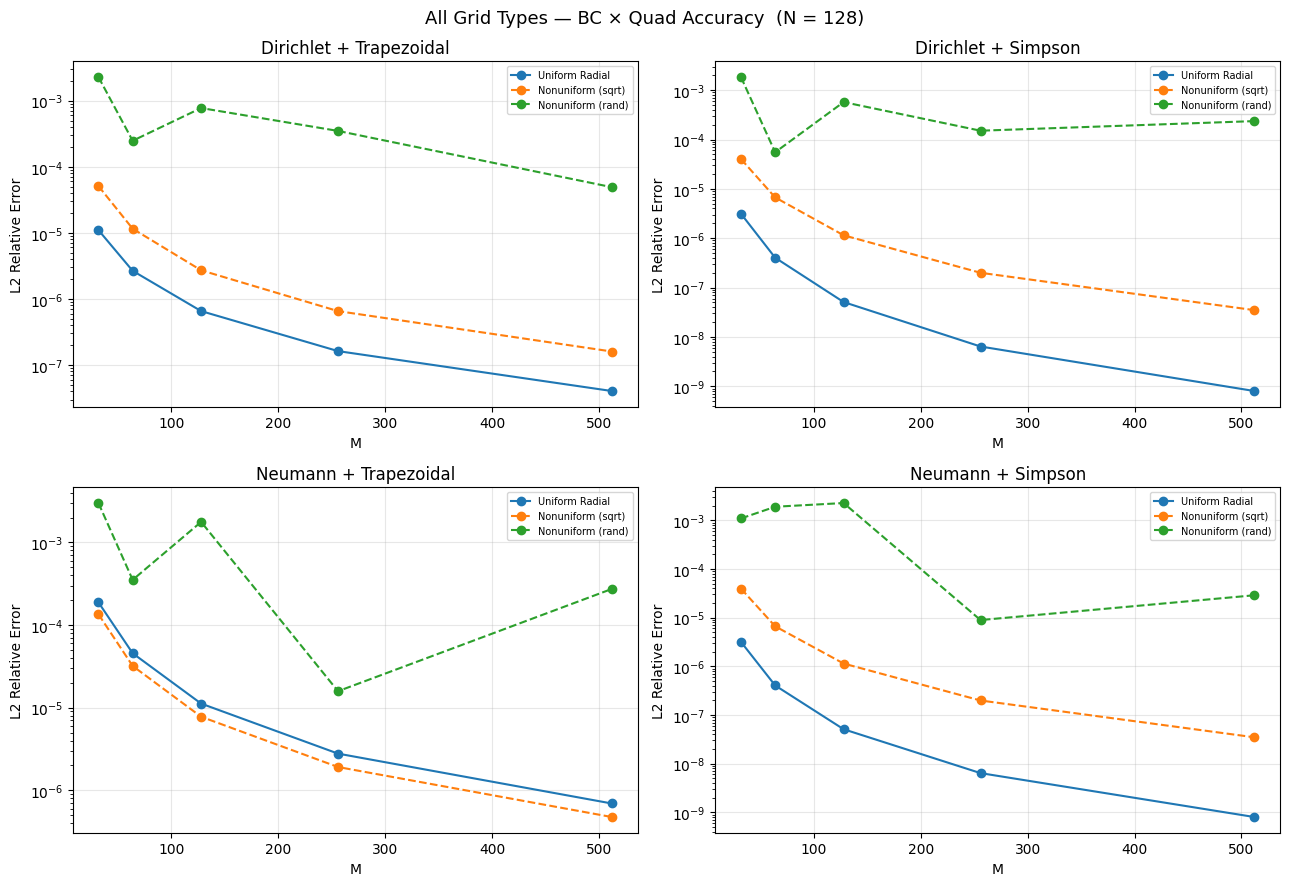

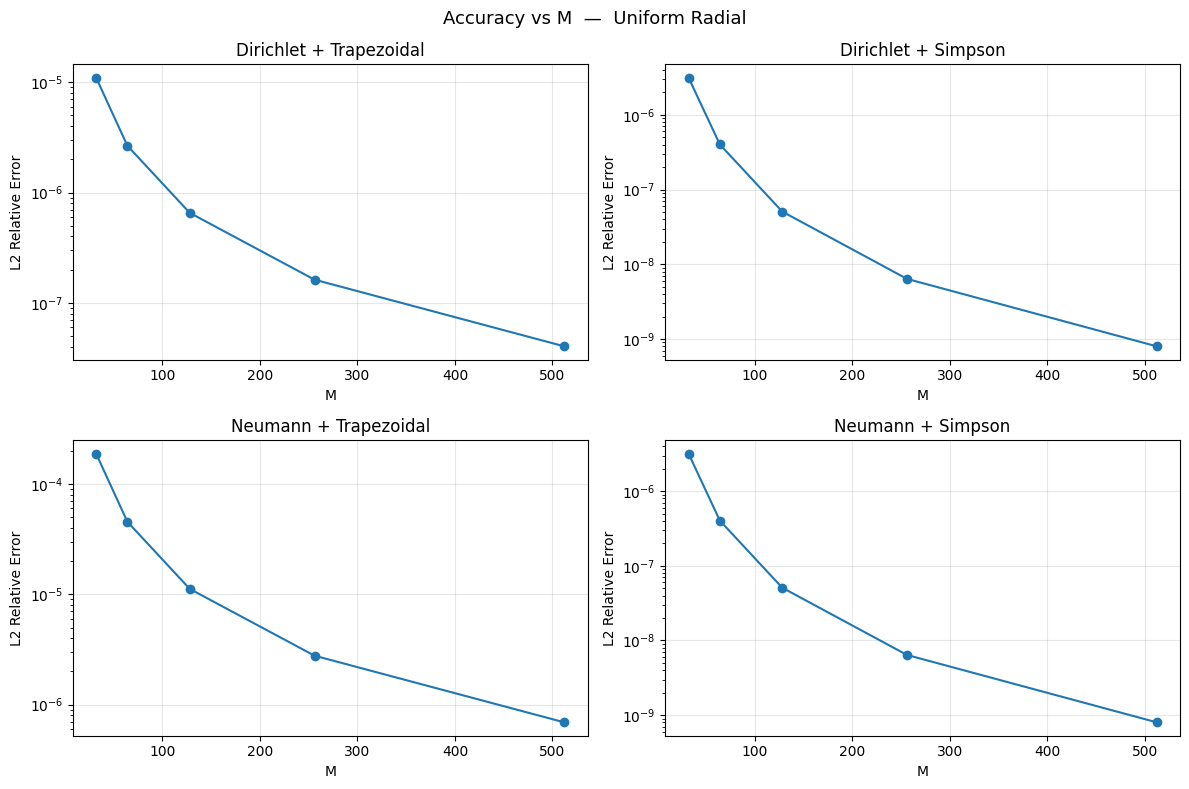

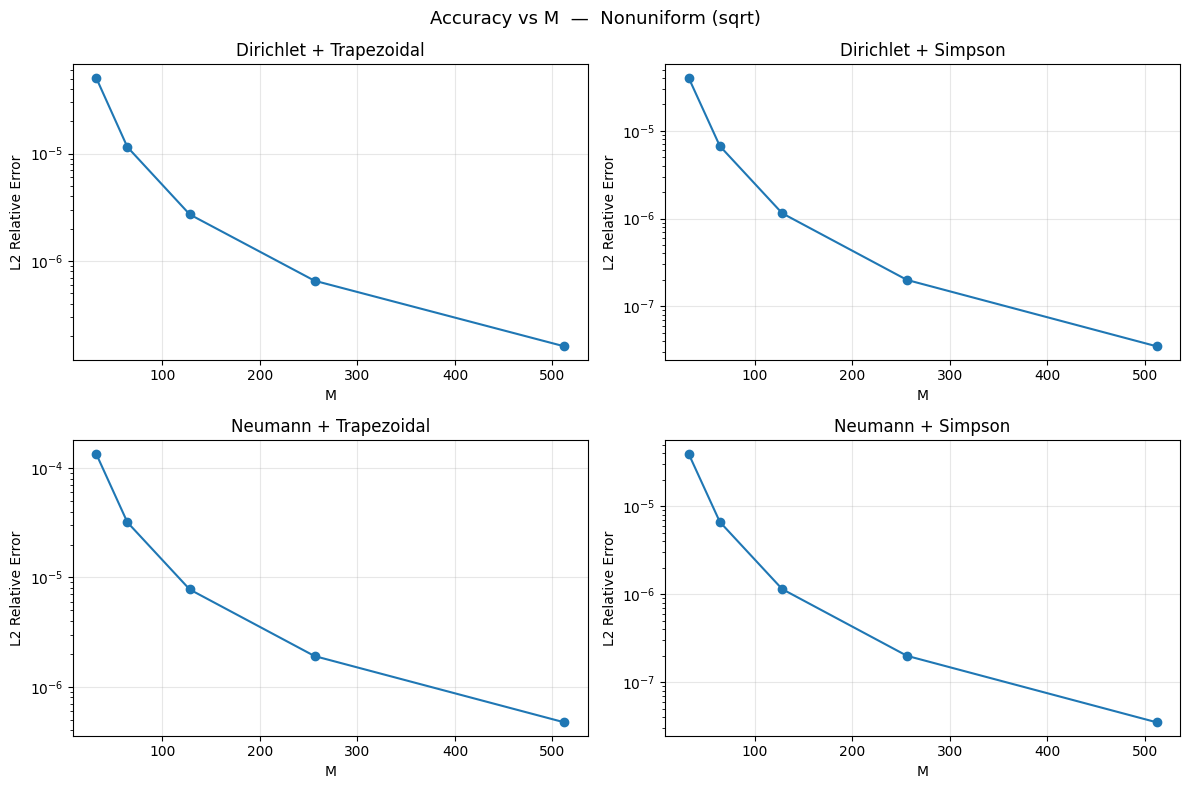

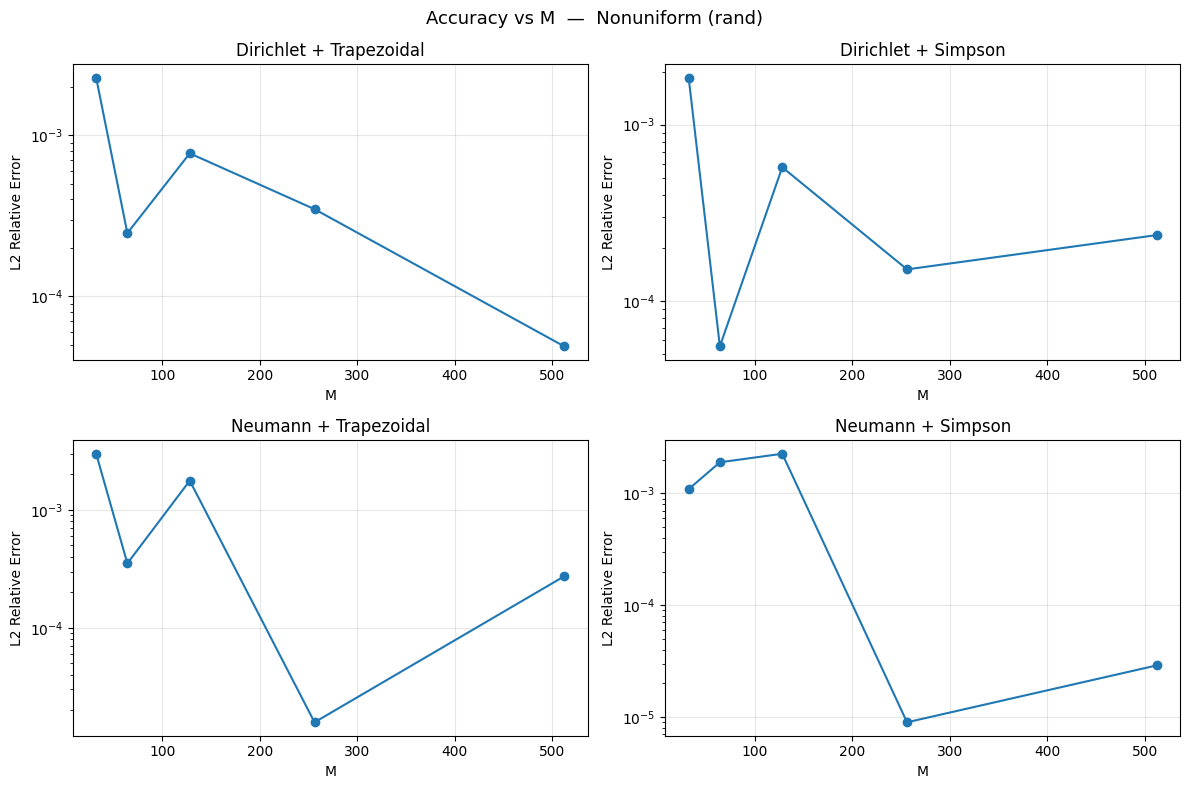

In [8]:
plot_radial_runtime_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])

plot_bc_quad_comparison_vs_M(df_bq, N_fixed=N_FIXED)


for method in ACTIVE_METHODS:
    plot_bc_quad_radial_accuracy(df_bq, method["label"])